In [51]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [52]:
# Load the dataset
df = pd.read_csv('creditcard.csv')  # Make sure this file is in the same folder

# Basic overview
print(df.shape)          # How many rows and columns?
print(df.head())         # First 5 rows
print(df.info())         # Data types
print(df['Class'].value_counts())  # 0 = Normal, 1 = Fraud

(284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V

In [53]:
# Step 2a: Dataset overview
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nMissing values:\n", df.isnull().sum())
print("\nBasic statistics:\n", df.describe())

Shape: (284807, 31)

Column names:
 ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Basic statistics:
                 Time            V1            V2            V3            V4  \
count  284807.000000  2.848070e+05  2.848070e+05  2.848070e+05  2.848070e+05   
mean    94813.859575  1.175161e-15  3.384974e-16 -1.379537e-15  2.094852e-15   
std     47488.145955  1.958696e+00  1.651309e+00  1.516255e+00  1.415869e+00   
min   

Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.17%


C:\Users\vijay\AppData\Local\Temp\ipykernel_20644\3914854441.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette=['steelblue', 'tomato'])


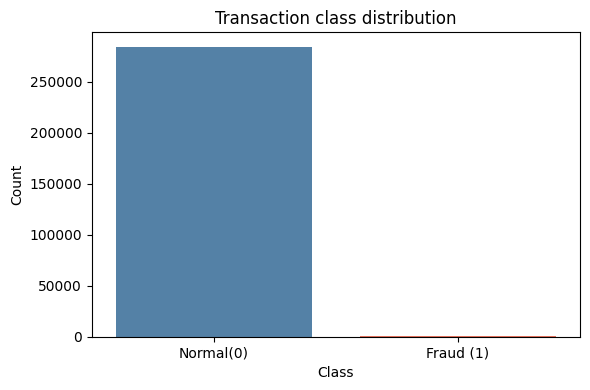

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

count = df['Class'].value_counts()
print(count)
print(f"\nFraud percentage: {count[1]/len(df)*100:.2f}%")
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette=['steelblue', 'tomato'])
plt.xticks([0,1],['Normal(0)','Fraud (1)'])
plt.title('Transaction class distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

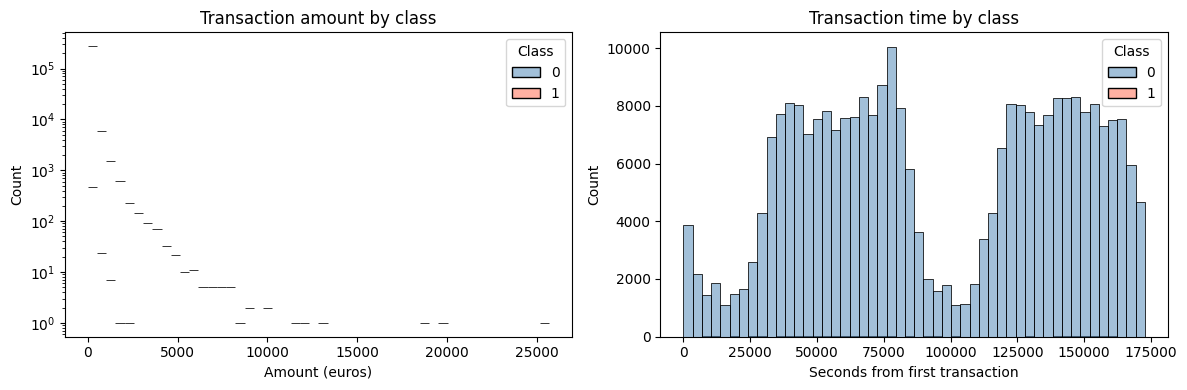

In [55]:
# Step 2c: Amount and Time distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Transaction Amount
sns.histplot(data=df, x='Amount', hue='Class', bins=50,ax=axes[0], palette=['steelblue', 'tomato'], log_scale=(False, True))
axes[0].set_title('Transaction amount by class')
axes[0].set_xlabel('Amount (euros)')
# Transaction Time
sns.histplot(data=df, x='Time', hue='Class', bins=50,ax=axes[1], palette=['steelblue', 'tomato'])
axes[1].set_title('Transaction time by class')
axes[1].set_xlabel('Seconds from first transaction')
plt.tight_layout()
plt.show()



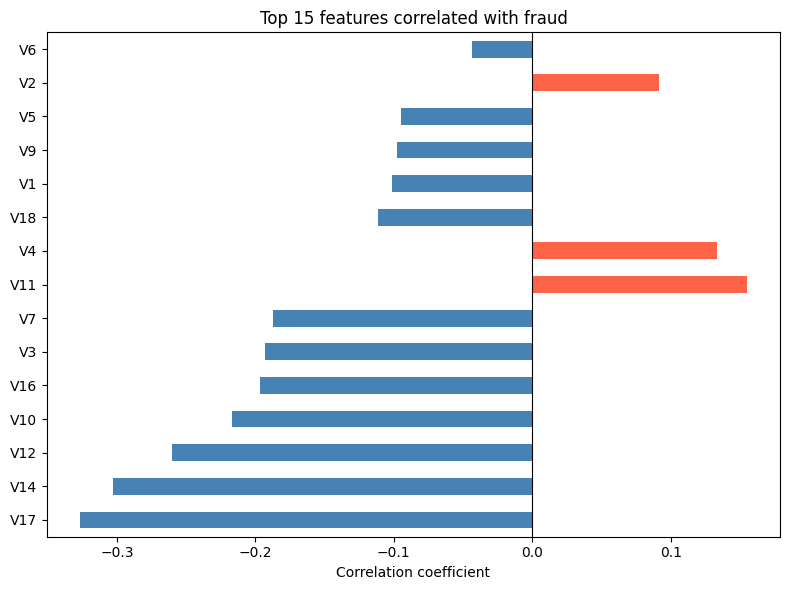

In [56]:
# Step 2d:Correlation with the Class label
correlation = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
plt.figure(figsize=(8, 6))
correlation.head(15).plot(kind='barh',color=['tomato' if x > 0 else'steelblue' for x in correlation.head(15)])
plt.title('Top 15 features correlated with fraud')
plt.xlabel('Correlation coefficient')
plt.axvline(0,color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

In [57]:
#Step 3a:drop the time coloumn
df = df.drop(columns=['Time'])
print("Columns after dropping Time: ",df.shape[1])

Columns after dropping Time:  30


In [58]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
print("Amount column after scaling:")
print(df['Amount'].describe())

Amount column after scaling:
count    2.848070e+05
mean    -3.672378e-17
std      1.000002e+00
min     -3.532294e-01
25%     -3.308401e-01
50%     -2.652715e-01
75%     -4.471707e-02
max      1.023622e+02
Name: Amount, dtype: float64


In [73]:
from imblearn.over_sampling import SMOTE
# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class']
print("Before SMOTE:")
print(y.value_counts())
# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)
print("\nAfter SMOTE:")
print(y_resampled.value_counts())

Before SMOTE:
Class
0    284315
1       492
Name: count, dtype: int64

After SMOTE:
Class
0    284315
1    284315
Name: count, dtype: int64


In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled,
    test_size=0.2,        # 20% for testing
    random_state=42,      # for reproducibility
    stratify=y_resampled  # keeps fraud ratio equal in both splits
)
print(f"Training set size:{X_train.shape}")
print(f"Test set size:    {X_test.shape}")

Training set size:(454904, 29)
Test set size:    (113726, 29)


In [77]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
# Train the model
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
# Predict on test data
lr_pred = lr_model.predict(X_test)
print("===Logistic Regression Results ===")
print(classification_report(y_test, lr_pred, target_names=['Normal', 'Fraud']))

===Logistic Regression Results ===
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.95     56863
       Fraud       0.97      0.92      0.94     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726



In [78]:
from sklearn.ensemble import RandomForestClassifier
# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
# Predict
rf_pred = rf_model.predict(X_test)
print("===Random Forest Results ===")
print(classification_report(y_test, rf_pred, target_names=['Normal', 'Fraud']))

===Random Forest Results ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [89]:
from xgboost import XGBClassifier
# Train the model
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb_model.fit(X_train, y_train)
# Predict
xgb_pred = xgb_model.predict(X_test)
print("=== XGBoost Results ===")
print(classification_report(y_test, xgb_pred, target_names=['Normal', 'Fraud']))

c:\Users\vijay\OneDrive\Desktop\Machine Learning Projects\Credit_Card_Fraud_Detection\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:03:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== XGBoost Results ===
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [82]:
!pip install xgboost


  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
import joblib
joblib.dump(lr_model,  'lr_model.pkl')
joblib.dump(rf_model,  'rf_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')
print("All models saved successfully!")

All models saved successfully!


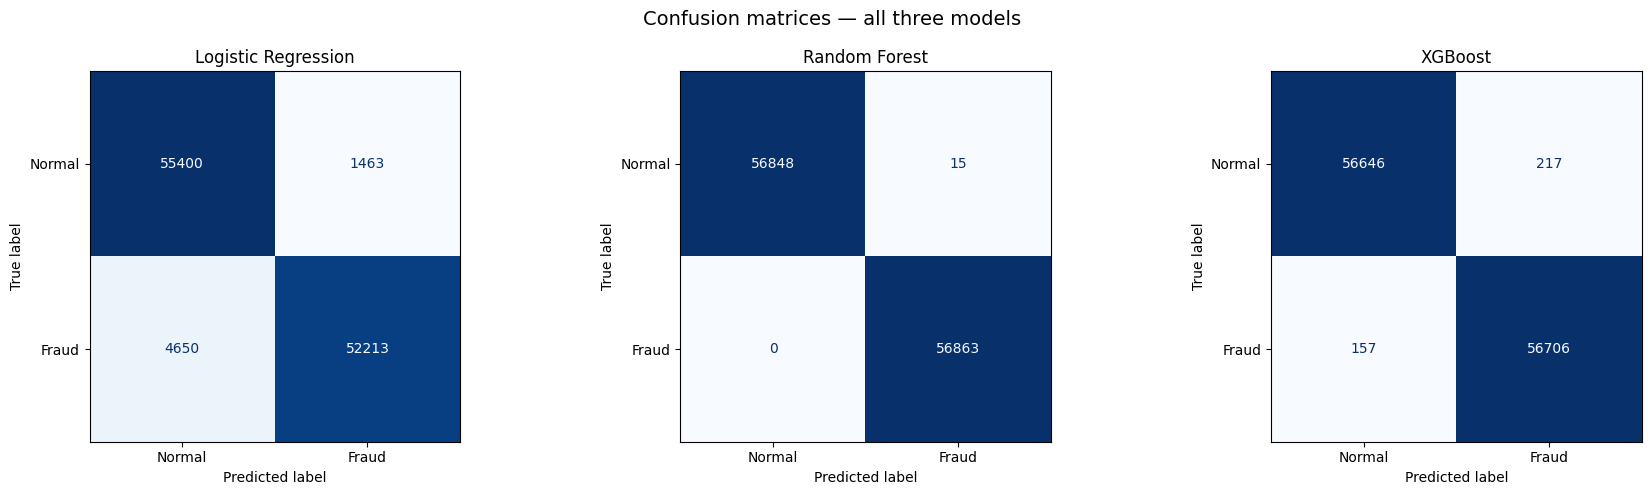

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
models = {
    'Logistic Regression': (lr_model, lr_pred),
    'Random Forest':       (rf_model, rf_pred),
    'XGBoost':             (xgb_model, xgb_pred)
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, (model, pred)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Normal', 'Fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.suptitle('Confusion matrices — all three models', fontsize=14)
plt.tight_layout()
plt.show()

In [93]:
from sklearn.metrics import classification_report
for name, (model, pred) in models.items():
    print(f"\n{'='*40}")
    print(f"  {name}")
    print('='*40)
    print(classification_report(y_test, pred,
     target_names=['Normal', 'Fraud']))


  Logistic Regression
              precision    recall  f1-score   support

      Normal       0.92      0.97      0.95     56863
       Fraud       0.97      0.92      0.94     56863

    accuracy                           0.95    113726
   macro avg       0.95      0.95      0.95    113726
weighted avg       0.95      0.95      0.95    113726


  Random Forest
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726


  XGBoost
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56863
       Fraud       1.00      1.00      1.00     56863

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00

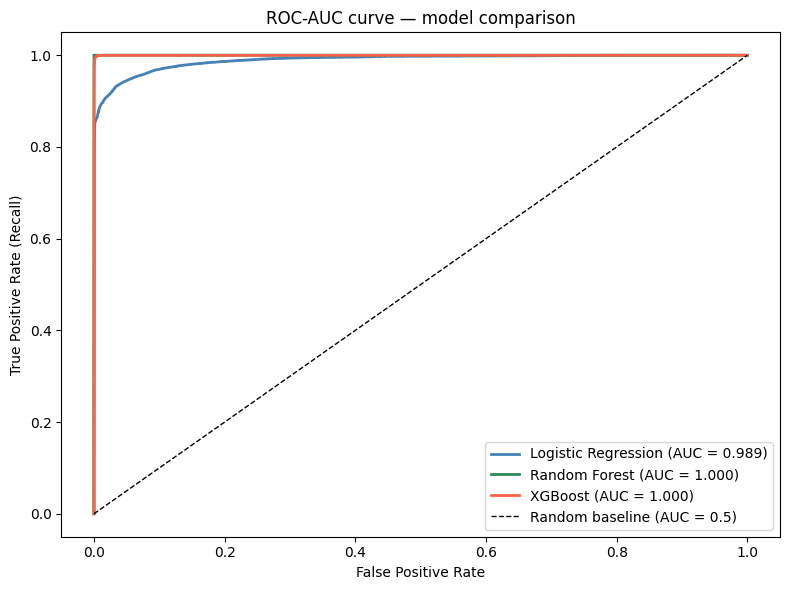

In [94]:
from sklearn.metrics import roc_curve, roc_auc_score
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'seagreen', 'tomato']
for (name, (model, _)), color in zip(models.items(), colors):
    # Get probability scores (not just 0/1 predictions)
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, lw=2)
# Random baseline
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random baseline (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC-AUC curve — model comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [95]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
results = []
for name, (model, pred) in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model':     name,
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
        'F1-Score':  round(f1_score(y_test, pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    })
results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.9727  0.9182    0.9447   0.9892
      Random Forest     0.9997  1.0000    0.9999   1.0000
            XGBoost     0.9962  0.9972    0.9967   0.9999


In [99]:
import shap
# Use XGBoost as it's our best model
explainer = shap.TreeExplainer(xgb_model)
# Compute SHAP values for the test set
# Use a sample of 1000 rows to keep it fast
X_test_sample = X_test[:1000]
shap_values = explainer.shap_values(X_test_sample)
print("SHAP values shape:", shap_values.shape)
# Should print: (1000, 29) — one score per feature per row

SHAP values shape: (1000, 29)


In [97]:
!pip install shap


  Using cached shap-0.51.0-cp314-cp314-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.65.1-cp314-cp314-win_amd64.whl.metadata (3.0 kB)
  Using cached llvmlite-0.47.0-cp314-cp314-win_amd64.whl.metadata (5.1 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached shap-0.51.0-cp314-cp314-win_amd64.whl (559 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached llvmlite-0.47.0-cp314-cp314-win_amd64.whl (39.2 MB)
Using cached numba-0.65.1-cp314-cp314-win_amd64.whl (2.8 MB)

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [slicer]
   ------------- -------------------------- 2/6 [llvmlite]
   ------------- -----


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


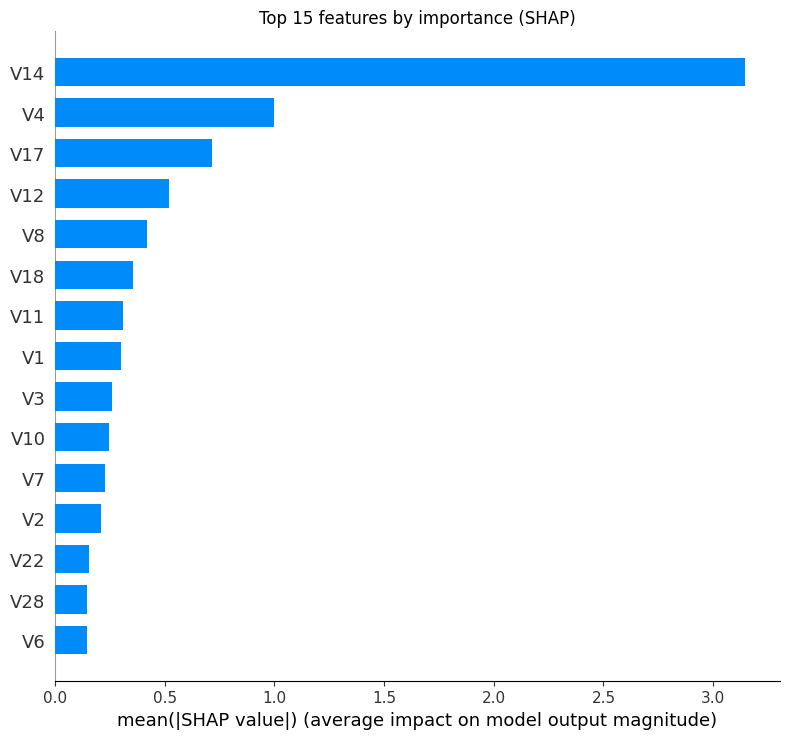

In [100]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_sample,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Top 15 features by importance (SHAP)")
plt.tight_layout()
plt.show()

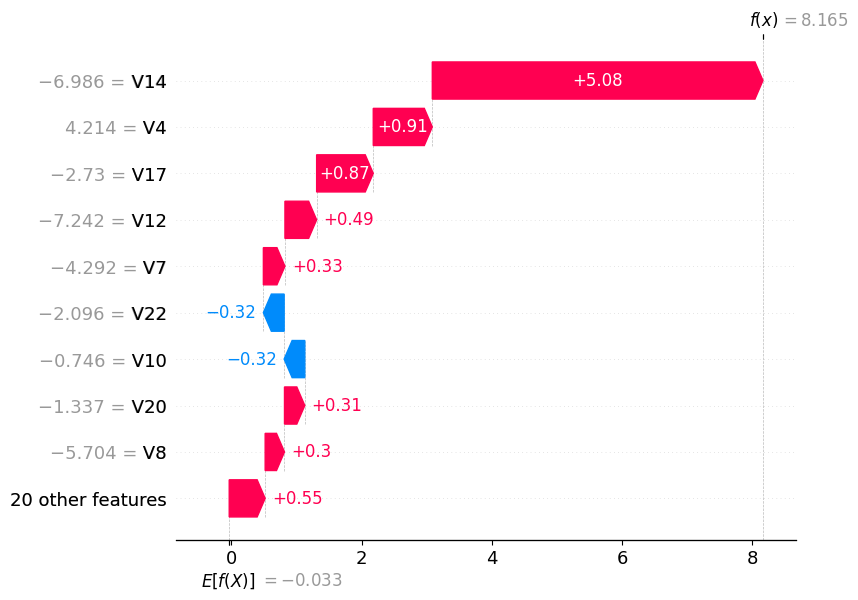

In [101]:
# Pick a fraud transaction from the test set
fraud_indices = [i for i, label in enumerate(y_test) if label == 1]
fraud_idx = fraud_indices[0]  # first fraud in test set
# Create explanation object
explanation = shap.Explanation(
    values=shap_values[fraud_idx],
    base_values=explainer.expected_value,
    data=X_test_sample.iloc[fraud_idx],
    feature_names=X_test.columns.tolist()
)
shap.plots.waterfall(explanation)

In [102]:
shap.initjs()  # initialise JavaScript for interactive plots
shap.force_plot(
    explainer.expected_value,
    shap_values[fraud_idx],
    X_test_sample.iloc[fraud_idx],
    feature_names=X_test.columns.tolist()
)

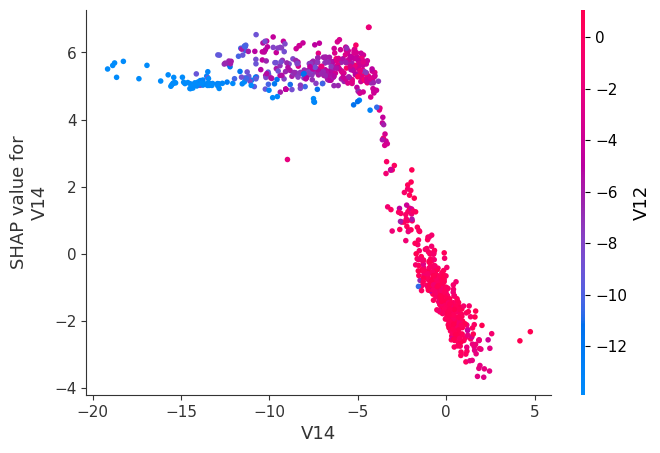

In [103]:
shap.dependence_plot(
    "V14",
    shap_values,
    X_test_sample,
    interaction_index="V12"  # colour by V12 interaction
)